In [444]:
#import necessary libraries
import joblib
import pandas as pd
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, roc_auc_score)

from IPython.display import display

In [445]:
#read excel data 
df_raw = pd.read_excel("../data/raw/E Commerce Dataset.xlsx", sheet_name="E Comm")

#display 5 first rows
df_raw.head(20)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139.19
6,50007,1,NaN,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
7,50008,1,NaN,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,122.93
8,50009,1,13.0,Phone,3,9.0,E wallet,Male,NaN,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,126.83
9,50010,1,NaN,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,122.93


In [446]:
#check the data in general
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

In [447]:
#checking in detail which columns has missing values  
missing = df_raw.isnull().sum()
missing[missing > 0]

Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64

In [448]:
#check duplicate
df_raw.duplicated().sum()

np.int64(0)

In [449]:
#check inconsistency
categorical_cols = df_raw.select_dtypes(exclude=['number']).columns

for col in categorical_cols:
    display(df_raw[col].value_counts())

PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

Gender
Male      3384
Female    2246
Name: count, dtype: int64

PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64

In [450]:
#check dtypes
df_raw.dtypes

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice               str
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode               str
Gender                             str
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                   str
SatisfactionScore                int64
MaritalStatus                      str
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object

In [451]:
#check statistic view
df_raw.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.50,54222.7500,55630.00
Churn,5630.0,0.168384,0.374240,0.0,0.00,0.00,0.0000,1.00
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.00,16.0000,61.00
CityTier,5630.0,1.654707,0.915389,1.0,1.00,1.00,3.0000,3.00
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.00,20.0000,127.00
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.00,3.0000,5.00
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.00,4.0000,6.00
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.00,4.0000,5.00
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.00,6.0000,22.00
Complain,5630.0,0.284902,0.451408,0.0,0.00,0.00,1.0000,1.00


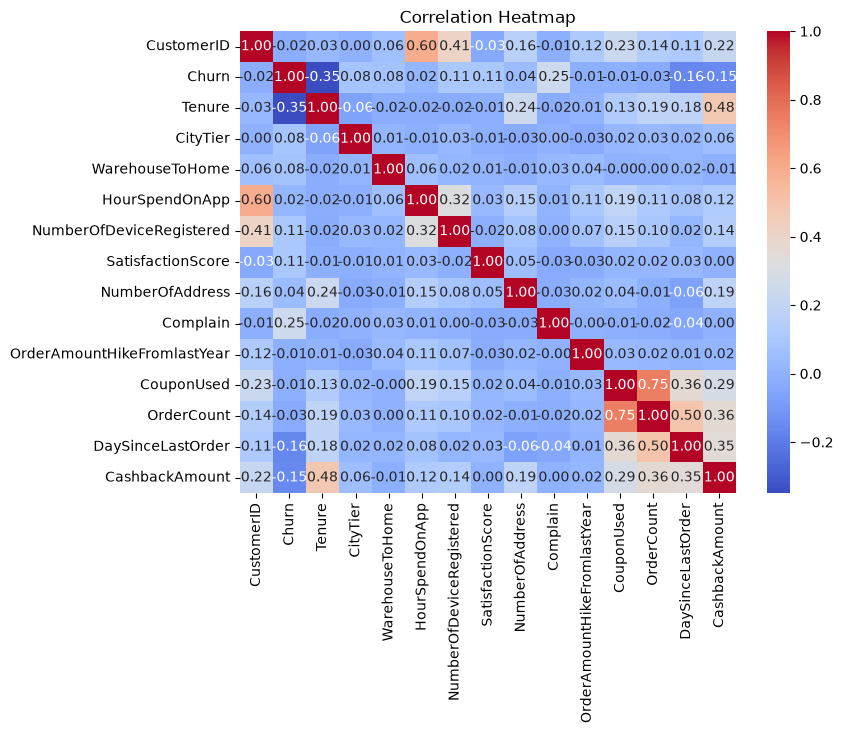

In [452]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix and plot
plt.figure(figsize=(8, 6))
sns.heatmap(df_raw.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

***Summary***:
- 5,630 rows and 20 columns (8 float, 7 integer, 5 categorical/string variables)
- 0 duplicate rows but found inconsistency
- DaySinceLastOrder (307 missing)
- OrderAmountHikeFromlastYear (265 missing)
- Tenure (264 missing)
- OrderCount (258 missing)
- CouponUsed (256 missing)
- HourSpendOnApp (255 missing)
- WarehouseToHome (251 missing)


- PreferredLoginDevice:	Mobile Phone (2,765) and Phone (1,231) represent the same category
- PreferredPaymentMode:CC (273) vs. Credit Card (1,501), COD (365) vs. Cash on Delivery (149) 
- PreferedOrderCat	Mobile Phone (1,271) and Mobile (809) are separated



- Churn Rate: 16.8% overall customer churn rate (Churn = 1) -> class imbalance
- Complaint Rate: 28.5% of customers registered a complaint in the last month. primary driver for churn and unnecessary CO₂ emissions from returns.
- Customer Tenure: Averages 10.2 months (ranging from brand-new customers at 0 months to loyal customers at 61 months). Churn is heavily concentrated in early customer life ($\le 3$ months)
- Order Behavior: Customers average 3 orders per month, with an average cashback reward of $177.22 and an app usage average of ~2.9 hours
- Logistics & Orders:** Avg. 3 orders/month ($177.22 avg. cashback)
- WarehouseToHome spikes up to 127 km (outliers)

**Handling Inconsistency**

In [453]:
#standardising inconsistencies
#login devices
df_raw['PreferredLoginDevice'] = df_raw['PreferredLoginDevice'].replace({'Mobile Phone': 'Mobile',
                                                                         'Phone': 'Mobile'})

#payment modes
df_raw['PreferredPaymentMode'] = df_raw['PreferredPaymentMode'].replace({'CC': 'Credit Card',
                                                                         'COD': 'Cash on Delivery'})

#order categories
df_raw['PreferedOrderCat'] = df_raw['PreferedOrderCat'].replace({'Mobile Phone': 'Mobile'})

In [454]:
#cross check inconsistency
categorical_cols = df_raw.select_dtypes(exclude=['number']).columns

for col in categorical_cols:
    display(df_raw[col].value_counts())

PreferredLoginDevice
Mobile      3996
Computer    1634
Name: count, dtype: int64

PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64

Gender
Male      3384
Female    2246
Name: count, dtype: int64

PreferedOrderCat
Mobile                2080
Laptop & Accessory    2050
Fashion                826
Grocery                410
Others                 264
Name: count, dtype: int64

MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64

**Handling Data Types**

In [455]:
#check dtypes
df_raw.dtypes

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice               str
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode               str
Gender                             str
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                   str
SatisfactionScore                int64
MaritalStatus                      str
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object

In [456]:
#convert count columns back to integers
count_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
              'OrderAmountHikeFromlastYear', 'CouponUsed', 
              'OrderCount', 'DaySinceLastOrder']
df_raw[count_cols] = df_raw[count_cols].astype('Int64')

#convert CustomerID to string
df_raw['CustomerID'] = df_raw['CustomerID'].astype(str)

#convert categorical variables to 'category' dtype
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 
            'PreferedOrderCat', 'MaritalStatus', 'CityTier']
df_raw[cat_cols] = df_raw[cat_cols].astype('category')

In [457]:
#cross check data data types
df_raw.dtypes

CustomerID                          str
Churn                             int64
Tenure                            Int64
PreferredLoginDevice           category
CityTier                       category
WarehouseToHome                   Int64
PreferredPaymentMode           category
Gender                         category
HourSpendOnApp                    Int64
NumberOfDeviceRegistered          int64
PreferedOrderCat               category
SatisfactionScore                 int64
MaritalStatus                  category
NumberOfAddress                   int64
Complain                          int64
OrderAmountHikeFromlastYear       Int64
CouponUsed                        Int64
OrderCount                        Int64
DaySinceLastOrder                 Int64
CashbackAmount                  float64
dtype: object

**Train_Test Split**

In [458]:
#define target & features
X = df_raw.drop(columns=['CustomerID', 'Churn'], errors='ignore')
y = df_raw['Churn']

In [459]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42, stratify=y)

**Imputing Data**

In [460]:
# Automatically grab all numerical columns from your dataframe to avoid missing any
num_cols_with_na = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

cat_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

# Now the numerical pipeline will safely process EVERY numeric column
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

cat_pipeline = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

# Integrate into column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols_with_na),
        ('cat', cat_pipeline, cat_cols),
    ]
)

# Fit & transform
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [461]:
# #define column types
# num_cols_with_na = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
#                     'OrderAmountHikeFromlastYear', 'CouponUsed', 
#                     'OrderCount', 'DaySinceLastOrder']

# cat_cols = ['PreferredLoginDevice',
#             'PreferredPaymentMode',
#             'Gender',
#             'PreferedOrderCat',
#             'MaritalStatus']


In [462]:
# #numerical imputation pipeline
# num_pipeline = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), 
#                                ('scaler', StandardScaler())])


# cat_pipeline = Pipeline(steps=[('onehot', OneHotEncoder (handle_unknown='ignore', sparse_output=False))])



In [463]:
# df_raw.info()

In [464]:
# #updated numerical columns after imputing
# num_cols = ['Tenure',
#             'WarehouseToHome',
#             'HourSpendOnApp',
#             'OrderAmountHikeFromlastYear',
#             'CouponUsed',
#             'OrderCount',
#             'DaySinceLastOrder',
#             'CityTier',
#             'NumberOfDeviceRegistered',
#             'SatisfactionScore',
#             'NumberOfAddress',
#             'Complain',
#             'CashbackAmount']

In [465]:
# #integrate into column transformer
# preprocessor = ColumnTransformer(transformers=[('num', num_pipeline, num_cols_with_na),
#                                                ('cat',cat_pipeline, cat_cols)])

In [466]:
# #fit & transform
# X_train_transformed = preprocessor.fit_transform(X_train)
# X_test_transformed = preprocessor.transform(X_test)

**Baseline**

In [467]:
#random forest
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_transformed, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [468]:
#evaluate probability baseline
y_pred = rf_baseline.predict(X_test_transformed)
y_proba = rf_baseline.predict_proba(X_test_transformed)[:, 1]

In [469]:
print('Baseline Random Forest')
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}')
print(f'Recall Score:  {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score:      {f1_score(y_test, y_pred):.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Baseline Random Forest
ROC-AUC Score: 0.9988
Recall Score:  0.8895
F1-Score:      0.9389

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       936
           1       0.99      0.89      0.94       190

    accuracy                           0.98      1126
   macro avg       0.99      0.94      0.96      1126
weighted avg       0.98      0.98      0.98      1126



**Feature Engineering**

In [470]:
#create few new features 
def add_engineered_features(df):
    df = df.copy()

    #sustainability & returns proxies
    df['Estimated_Returns'] = np.where(df['Complain'] == 1, np.ceil(df['OrderCount'] * 0.20),
                                                            np.ceil(df['OrderCount'] * 0.05))
    df['Estimated_CO2_kg'] = df['Estimated_Returns'] * 1.2

    #domain interaction ratios (avoiding division by zero with +1)
    df['Tenure_to_OrderCount_ratio'] = df['Tenure'] / (df['OrderCount'] + 1)
    df['Cashback_per_Order'] = df['CashbackAmount'] / (df['OrderCount'] + 1)
    df['Recency_to_Tenure_ratio'] = df['DaySinceLastOrder'] / (df['Tenure'] + 1)

    #categorical buckets
    df['TenureBucket'] = pd.cut (df['Tenure'], bins=[-1, 3, 12, 60, 100],
                                               labels=['0-3 Mos', '4-12 Mos', '1-5 Yrs', '5+ Yrs'])
    df['DistanceCategory'] = pd.cut (df['WarehouseToHome'], bins=[-1, 10, 20, 50, 200],
                                                            labels=['Close', 'Moderate', 'Far', 'Very Far'])

    return df

In [471]:
#feature engineering to train and test sets
X_train_fe = add_engineered_features(X_train)
X_test_fe = add_engineered_features(X_test)

In [472]:
# #updated numerical & categorical columns after feature engineering
# num_cols = ['Tenure',
#             'WarehouseToHome',
#             'HourSpendOnApp',
#             'NumberOfDeviceRegistered',
#             'SatisfactionScore',
#             'NumberOfAddress',
#             'Complain',
#             'OrderAmountHikeFromlastYear',
#             'CouponUsed',
#             'OrderCount',
#             'DaySinceLastOrder',
#             'CashbackAmount',
#             'Estimated_Returns',
#             'Estimated_CO2_kg',
#             'Tenure_to_OrderCount_ratio',
#             'Cashback_per_Order',
#             'Recency_to_Tenure_ratio']

# cat_cols = ['PreferredLoginDevice',
#             'PreferredPaymentMode',
#             'Gender',
#             'PreferedOrderCat',
#             'MaritalStatus',
#             'CityTier',
#             'TenureBucket',
#             'DistanceCategory']

In [473]:
num_cols = X_train_fe.select_dtypes(
    include=['int64', 'float64', 'int32', 'float32']
).columns.tolist()
cat_cols = X_train_fe.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

**XG Boost**

In [474]:
import sys
import ensurepip

ensurepip.bootstrap()

Looking in links: /var/folders/lt/2dp2k6b12vj25g_wlskpks300000gn/T/tmpx0ucl8w0


In [475]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [476]:
#import XGBClassifier
from xgboost import XGBClassifier

#calculate imbalance ratio from training target
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

#pipeline
xgb_pipeline = Pipeline (steps=[('preprocessor', preprocessor),('classifier', XGBClassifier (n_estimators=100,
                                                                                             learning_rate=0.1,
                                                                                             max_depth=5,
                                                                                             scale_pos_weight=scale_pos_weight,
                                                                                             random_state=42,
                                                                                             eval_metric='logloss'))])

#fit end-to-end on raw feature engineered 
xgb_pipeline.fit(X_train_fe, y_train)

#predict probability feature engineering
y_pred_xgb = xgb_pipeline.predict(X_test_fe)
y_proba_xgb = xgb_pipeline.predict_proba(X_test_fe)[:, 1]

In [477]:
#display evaluation metrics
print('XGBoost Model')
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}')
print(f'Recall Score:  {recall_score(y_test, y_pred_xgb):.4f}')
print(f'F1-Score:      {f1_score(y_test, y_pred_xgb):.4f}')

#display classification report
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_xgb))

print('\nClassification Report:')
print(classification_report(y_test, y_pred_xgb))

XGBoost Model
ROC-AUC Score: 0.9859
Recall Score:  0.9368
F1-Score:      0.8298

Confusion Matrix:
[[875  61]
 [ 12 178]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       936
           1       0.74      0.94      0.83       190

    accuracy                           0.94      1126
   macro avg       0.87      0.94      0.89      1126
weighted avg       0.95      0.94      0.94      1126



**Threshold Tuning**

In [478]:
#predicted probabilities for the positive class (Churn = 1)
y_proba_xgb = xgb_pipeline.predict_proba(X_test_fe)[:, 1]

#test different thresholds from 0.1 to 0.9
thresholds = np.arange(0.1, 0.95, 0.05)
best_threshold = 0.5
best_f1 = 0

print(f"{'Threshold':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print('-' * 46)

for thresh in thresholds:
    y_pred_thresh = (y_proba_xgb >= thresh).astype(int)
    p = precision_score(y_test, y_pred_thresh, zero_division=0)
    r = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)

    print(f'{thresh:<10.2f} | {p:<10.4f} | {r:<10.4f} | {f1:<10.4f}')

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f'\n✨ Best Threshold based on F1-Score: {best_threshold:.2f} (F1: {best_f1:.4f})')

Threshold  | Precision  | Recall     | F1-Score  
----------------------------------------------
0.10       | 0.3647     | 1.0000     | 0.5345    
0.15       | 0.4398     | 1.0000     | 0.6109    
0.20       | 0.5080     | 1.0000     | 0.6738    
0.25       | 0.5676     | 0.9947     | 0.7228    
0.30       | 0.6097     | 0.9947     | 0.7560    
0.35       | 0.6238     | 0.9947     | 0.7667    
0.40       | 0.6679     | 0.9737     | 0.7923    
0.45       | 0.7176     | 0.9632     | 0.8225    
0.50       | 0.7448     | 0.9368     | 0.8298    
0.55       | 0.7864     | 0.9105     | 0.8439    
0.60       | 0.8116     | 0.8842     | 0.8463    
0.65       | 0.8438     | 0.8526     | 0.8482    
0.70       | 0.8626     | 0.8263     | 0.8441    
0.75       | 0.8844     | 0.8053     | 0.8430    
0.80       | 0.9226     | 0.7526     | 0.8290    
0.85       | 0.9466     | 0.6526     | 0.7726    
0.90       | 0.9600     | 0.5053     | 0.6621    

✨ Best Threshold based on F1-Score: 0.65 (F1: 0.8482

In [479]:
#apply optimal threshold of 0.60
optimal_threshold = 0.65
y_pred_optimal = (y_proba_xgb >= optimal_threshold).astype(int)

#display final classification report using the tuned threshold
print(f'Evaluation at Optimal Threshold ({optimal_threshold})')
print(classification_report(y_test, y_pred_optimal))

Evaluation at Optimal Threshold (0.65)
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       936
           1       0.84      0.85      0.85       190

    accuracy                           0.95      1126
   macro avg       0.91      0.91      0.91      1126
weighted avg       0.95      0.95      0.95      1126



**Feature Importance Plot**

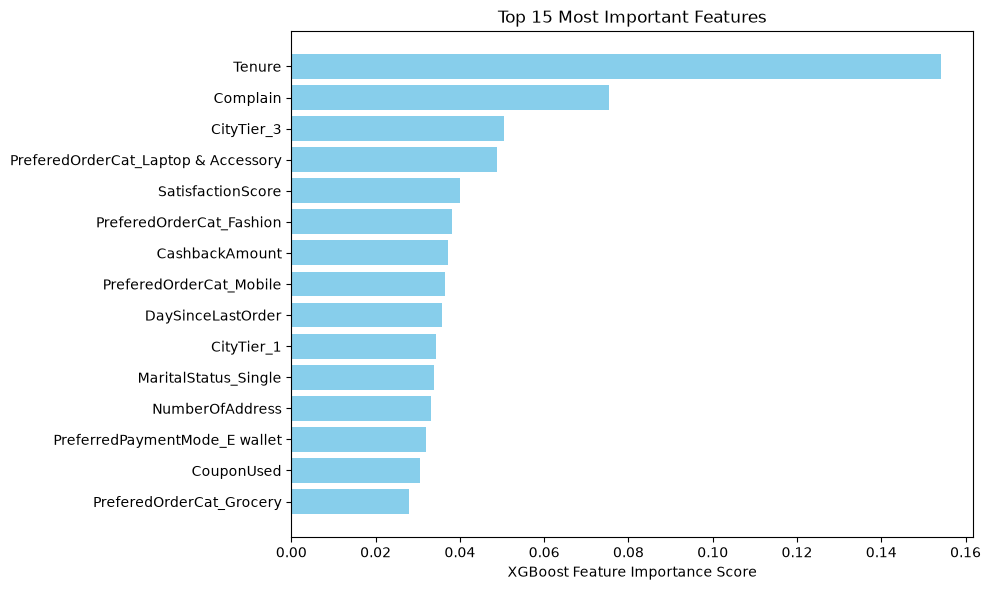

In [480]:
#import matplotlib
import matplotlib.pyplot as plt

#extract feature names
all_feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()

#cleaned feature names
cleaned_feature_names = [name.replace('num__', '').replace('cat__', '') for name in all_feature_names]

#get feature importances from the trained XGBoost model
importances = xgb_pipeline.named_steps['classifier'].feature_importances_

#visualisation
feat_imp_df = pd.DataFrame({'Feature': cleaned_feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

#plot top 15 features
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'].head(15)[::-1],
         feat_imp_df['Importance'].head(15)[::-1],
         color='skyblue')

plt.xlabel('XGBoost Feature Importance Score')
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.show()

In [481]:
%pip install shap


[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Generating SHAP Summary Plot...


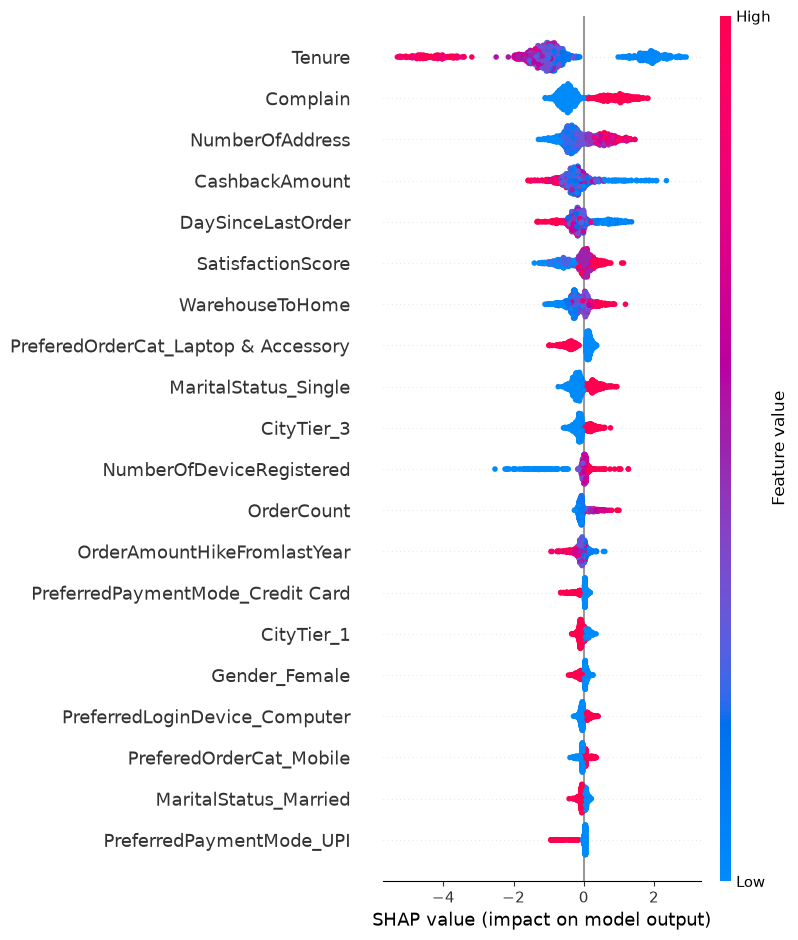

In [482]:
#import shap
import shap

#extract preprocessed training and testing data from pipeline using your fitted column transformer
X_train_transformed = xgb_pipeline.named_steps['preprocessor'].transform(X_train_fe)
X_test_transformed = xgb_pipeline.named_steps['preprocessor'].transform(X_test_fe)

#cleaned feature names 
all_feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()
cleaned_feature_names = [name.replace('num__', '').replace('cat__', '')for name in all_feature_names]

#initialise SHAP TreeExplainer using trained XGBoost model
model = xgb_pipeline.named_steps['classifier']
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

#generate summary plot 
print('Generating SHAP Summary Plot...')
shap.summary_plot(shap_values, X_test_transformed, feature_names=cleaned_feature_names)

In [483]:
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

In [484]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   CustomerID                   5630 non-null   str     
 1   Churn                        5630 non-null   int64   
 2   Tenure                       5366 non-null   Int64   
 3   PreferredLoginDevice         5630 non-null   category
 4   CityTier                     5630 non-null   category
 5   WarehouseToHome              5379 non-null   Int64   
 6   PreferredPaymentMode         5630 non-null   category
 7   Gender                       5630 non-null   category
 8   HourSpendOnApp               5375 non-null   Int64   
 9   NumberOfDeviceRegistered     5630 non-null   int64   
 10  PreferedOrderCat             5630 non-null   category
 11  SatisfactionScore            5630 non-null   int64   
 12  MaritalStatus                5630 non-null   category
 13  NumberOfAddres

In [485]:
import os

# Go up one level from the 'notebooks' folder to the project root, then into data/processed
file_path = os.path.abspath(
    os.path.join('..', 'data', 'processed', 'clean_data_ML.csv')
)

# Ensure the directory exists relative to root just in case
os.makedirs(os.path.dirname(file_path), exist_ok=True)

# Save the dataframe
df_raw.to_csv(file_path, index=False)
print(f'Successfully saved to: {file_path}')

Successfully saved to: /Users/esterbleskadit/DPP-portofolio-project/data/processed/clean_data_ML.csv


In [486]:
import pickle

with open('xgb_pipeline.pkl', 'wb') as f:
  pickle.dump(xgb_pipeline, f)

In [487]:
# Check what features the pipeline or preprocessor expects
if hasattr(xgb_pipeline, 'feature_names_in_'):
  print(xgb_pipeline.feature_names_in_)
else:
  # If it's a scikit-learn Pipeline with a preprocessor step
  print(xgb_pipeline.named_steps['preprocessor'].get_feature_names_out())

['Tenure' 'PreferredLoginDevice' 'CityTier' 'WarehouseToHome'
 'PreferredPaymentMode' 'Gender' 'HourSpendOnApp'
 'NumberOfDeviceRegistered' 'PreferedOrderCat' 'SatisfactionScore'
 'MaritalStatus' 'NumberOfAddress' 'Complain'
 'OrderAmountHikeFromlastYear' 'CouponUsed' 'OrderCount'
 'DaySinceLastOrder' 'CashbackAmount' 'Estimated_Returns'
 'Estimated_CO2_kg' 'Tenure_to_OrderCount_ratio' 'Cashback_per_Order'
 'Recency_to_Tenure_ratio' 'TenureBucket' 'DistanceCategory']


In [489]:
import numpy as np

# Check if any NaNs exist in the transformed training matrix
has_nans = np.isnan(X_train_transformed).any()
print('Are there any remaining NaNs in X_train_transformed?', has_nans)

Are there any remaining NaNs in X_train_transformed? False


In [490]:
# Check missing values per column in your raw or feature-engineered dataframe
print(X_train_fe.isnull().sum())

Tenure                         213
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                206
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 197
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    208
CouponUsed                     208
OrderCount                     212
DaySinceLastOrder              247
CashbackAmount                   0
Estimated_Returns              212
Estimated_CO2_kg               212
Tenure_to_OrderCount_ratio     425
Cashback_per_Order             212
Recency_to_Tenure_ratio        460
TenureBucket                   213
DistanceCategory               206
dtype: int64
